In [1]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Copy the zip file from My Drive to the local Colab storage
# Note: Copying it locally first makes reading images during training MUCH faster!
!cp "/content/drive/MyDrive/anime_faces.zip" "/content/anime_faces.zip"

# 3. Unzip the dataset into a new folder
# The '-q' flag keeps it quiet so it doesn't crash your browser by printing thousands of file names
!unzip -q "/content/anime_faces.zip" -d "/content/"

print("Dataset copied and unzipped successfully!")

Mounted at /content/drive
Dataset copied and unzipped successfully!


In [2]:
# installation cell
!pip install ipywidgets piq tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.6 MB/s eta 0:00:00


In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from piq import ssim as ssim_func
import os
import shutil
from tqdm import tqdm
from torch.utils.data import TensorDataset

In [2]:
# HYPERPARAMETERS
total_epochs = 40
warmup_epochs = 10
beta_initial = 0.0
beta_target = 3.0
latent_dim = 16
learning_rate = 5e-5
batch_size = 64

In [3]:
# 1. Basic transformation
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

# 2. Point to your image folder
dataset = datasets.ImageFolder(root='./anime_faces/train', transform=transform)
val_dataset = datasets.ImageFolder(root='./anime_faces/val',transform=transform)
# 3. Create the DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset,batch_size=batch_size,num_workers=os.cpu_count())

# 4. Test it: Pull one batch of images
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([64, 3, 48, 48])


In [4]:
# def cache_dataset(dataset):
#     """Load all images into RAM as a single tensor batch."""
#     loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=False)
#     images_list, labels_list = [], []
#     for imgs, lbls in tqdm(loader, desc="Caching to RAM"):
#         images_list.append(imgs)
#         labels_list.append(lbls)
#     return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# print("Caching train set...")
# train_cached = cache_dataset(dataset)
# print("Caching val set...")
# val_cached   = cache_dataset(val_dataset)

# # Replace the loaders with ram based loaders
# train_loader = DataLoader(train_cached, batch_size=batch_size, shuffle=True,  num_workers=0)
# val_loader   = DataLoader(val_cached,   batch_size=batch_size, shuffle=False, num_workers=0)
# print(f"Done. Train: {len(train_cached)} | Val: {len(val_cached)}")

In [5]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()

        # Encoder: 3x48x48 -> Latent Space
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # 24x24
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 12x12
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 6x6
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 3x3
            nn.ReLU(),
            nn.Flatten()
        )

        # Latent vectors (mu and log_var)
        # 256 * 3 * 3 = 2304
        self.fc_mu = nn.Linear(2304, latent_dim)
        self.fc_logvar = nn.Linear(2304, latent_dim)

        # Decoder: Latent Space -> 3x48x48
        self.decoder_input = nn.Linear(latent_dim, 2304)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 3, 3)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 6x6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 12x12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 24x24
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # 48x48
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """The Reparameterization Trick: z = mu + std * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

# --- The Beta-VAE Loss Function ---
def loss_function(recon_x, x, mu, logvar, beta=4.0):
    # Structural Loss (SSIM)
    ssim_val = ssim_func(recon_x, x, data_range=1.0, reduction='mean')
    reconstruction_loss = (1 - ssim_val) * (48*48*3)

    # 2. KL Divergence
    kld_element = 1 + logvar - mu.pow(2) - logvar.exp()
    kld_loss = -0.5 * torch.mean(torch.sum(kld_element, dim=1))

    # Total loss
    total_loss = reconstruction_loss + (beta * kld_loss)
    return total_loss, reconstruction_loss, kld_loss

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
model = BetaVAE(latent_dim=latent_dim).to(device)

cuda


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

In [8]:
def train_epoch(model, dataloader, optimizer, device, beta_weight=4.0):
    model.train()

    # Sum of losses
    running_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", leave=False)

    for images, _ in progress_bar:
        images = images.to(device)
        batch_size = images.size(0)

        # Forward pass
        recon_batch, mu, logvar = model(images)
        batch_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # Backward pass
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        # Accumulate sums (mean loss * batch_size = sum loss)
        running_loss += batch_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

        # Display the current batch mean loss in the progress bar
        progress_bar.set_postfix({
            "Loss": f"{batch_loss.item():.4f}",
            "Rec": f"{batch_rec.item():.4f}",
            "KLD": f"{batch_kld.item():.4f}"
        })

    # Calculate true epoch averages
    dataset_size = len(dataloader.dataset)
    epoch_loss = running_loss / dataset_size
    epoch_rec = running_rec / dataset_size
    epoch_kld = running_kld / dataset_size

    return epoch_loss, epoch_rec, epoch_kld

In [9]:
def save_checkpoint(state_dict, is_best, folder="./checkpoints", filename="checkpoint.pth"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    # Save the latest epoch
    torch.save(state_dict, filepath)

    # If it's the best so far, overwrite the best model file
    if is_best:
        best_filepath = os.path.join(folder, "model_best.pth")
        shutil.copyfile(filepath, best_filepath)
        # Updated key here to match the new payload!
        print(f"--> ✨ New best model saved! Val Loss: {state_dict['best_val_loss']:.4f}")

In [10]:
# --- Validation Function ---
@torch.no_grad()
def validate_epoch(model, dataloader, device, beta_weight=4.0):
    """Runs a single pass over the validation set without tracking gradients."""
    model.eval()

    running_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)

        # Forward pass only
        recon_batch, mu, logvar = model(images)
        batch_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # Accumulate sums
        running_loss += batch_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

    dataset_size = len(dataloader.dataset)
    return running_loss / dataset_size, running_rec / dataset_size, running_kld / dataset_size

In [11]:
checkpoint_path = "./checkpoints/checkpointv1.pth"

# --- Setup & Nomenclature ---
best_val_loss = float('inf')

start_epoch = 1

# Clean history tracking, now actually tracking validation
history = {
    'train_loss': [], 'train_rec': [], 'train_kld': [],
    'val_loss': [], 'val_rec': [], 'val_kld': [],
    'learning_rate': []
}

# Check if the file actually exists
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Loading...")

    # Load the model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restore the model and optimizer memory
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    # Restore our trackers
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    history = checkpoint['history']

    print(f"Resuming training from Epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch.")

No checkpoint found. Starting training from scratch.


In [12]:
def cache_dataset_vram(dataset, device):
    """Load all images directly into VRAM (GPU memory) as a single tensor batch."""

    # pin_memory=True speeds up the initial transfer from CPU to GPU
    loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=True)
    images_list, labels_list = [], []

    for imgs, lbls in tqdm(loader, desc=f"Caching to VRAM ({device})"):
        # Move data to the GPU immediately
        # non_blocking=True allows asynchronous data transfers, speeding up the process
        images_list.append(imgs.to(device, non_blocking=True))
        labels_list.append(lbls.to(device, non_blocking=True))

    return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# --- How to use it ---
# # Make sure 'device' is defined before calling this!
print("Caching train set to VRAM...")
train_cached_vram = cache_dataset_vram(dataset, device)
print("Caching val set to VRAM...")
val_cached_vram   = cache_dataset_vram(val_dataset, device)

# # Replace the loaders with VRAM-based loaders
# # IMPORTANT: num_workers MUST be 0 here because multiprocessing cannot handle GPU tensors
train_loader = DataLoader(train_cached_vram, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_cached_vram,   batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Done. Train: {len(train_cached_vram)} | Val: {len(val_cached_vram)}")

Caching train set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 245/245 [00:34<00:00,  7.18it/s]


Caching val set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 4/4 [00:00<00:00,  5.01it/s]

Done. Train: 62541 | Val: 1024


In [13]:
print(f"Starting training on device: {device}")

for epoch in range(start_epoch, total_epochs + 1):
    # Step function for Beta Warmup
    current_beta = min(beta_target, beta_initial + (beta_target / warmup_epochs) * (epoch - 1))
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch}/{total_epochs}] | Beta: {current_beta:.1f} | LR: {current_lr}")

    # 1. Run one training epoch
    train_loss, train_rec, train_kld = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        beta_weight=current_beta
    )

    # 2. Run one validation epoch
    val_loss, val_rec, val_kld = validate_epoch(
        model=model,
        dataloader=val_loader,
        device=device,
        beta_weight=current_beta
    )

    # 3. Record history
    history['train_loss'].append(train_loss)
    history['train_rec'].append(train_rec)
    history['train_kld'].append(train_kld)

    history['val_loss'].append(val_loss)
    history['val_rec'].append(val_rec)
    history['val_kld'].append(val_kld)

    history['learning_rate'].append(current_lr)

    # 4. Print logs
    print(f"  Train -> Loss: {train_loss:.4f} (Rec: {train_rec:.4f}, KLD: {train_kld:.4f})")
    print(f"  Val   -> Loss: {val_loss:.4f} (Rec: {val_rec:.4f}, KLD: {val_kld:.4f})")

    # 5. Check if this is the best model (Evaluating based on VALIDATION loss)
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    # 6. Save Checkpoint payload
    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }
    save_checkpoint(checkpoint_payload, is_best)

    scheduler.step(val_loss)

Starting training on device: cuda
Epoch [1/40] | Beta: 0.0 | LR: 5e-05


/tmp/ipykernel_20070/2757360949.py:58: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


  Train -> Loss: 4945.4860 (Rec: 4945.4860, KLD: 7385.4297)
  Val   -> Loss: 4867.4315 (Rec: 4867.4315, KLD: 5032.0559)
--> ✨ New best model saved! Val Loss: 4867.4315
Epoch [2/40] | Beta: 0.3 | LR: 3.900175749570152e-05


  Train -> Loss: 4556.7677 (Rec: 4514.1894, KLD: 141.9274)
  Val   -> Loss: 4412.6263 (Rec: 4389.2127, KLD: 78.0452)
--> ✨ New best model saved! Val Loss: 4412.6263
Epoch [3/40] | Beta: 0.6 | LR: 3.8908811119978076e-05


  Train -> Loss: 4088.3319 (Rec: 4054.0016, KLD: 57.2172)
  Val   -> Loss: 4041.7436 (Rec: 4008.7943, KLD: 54.9155)
--> ✨ New best model saved! Val Loss: 4041.7436
Epoch [4/40] | Beta: 0.9 | LR: 1.2293646291232373e-06


...

  Train -> Loss: 3529.2640 (Rec: 3424.3268, KLD: 34.9791)
  Val   -> Loss: 3722.2246 (Rec: 3618.6334, KLD: 34.5304)
Epoch [37/40] | Beta: 3.0 | LR: 1.3730081143120612e-06


  Train -> Loss: 3528.2675 (Rec: 3423.3308, KLD: 34.9789)
  Val   -> Loss: 3718.8132 (Rec: 3615.2964, KLD: 34.5056)
--> ✨ New best model saved! Val Loss: 3718.8132
Epoch [38/40] | Beta: 3.0 | LR: 1.1063625029929816e-06


  Train -> Loss: 3528.2566 (Rec: 3423.0954, KLD: 35.0537)
  Val   -> Loss: 3719.8450 (Rec: 3615.5700, KLD: 34.7583)
Epoch [39/40] | Beta: 3.0 | LR: 1.00181573533988e-06


  Train -> Loss: 3527.3447 (Rec: 3422.2987, KLD: 35.0153)
  Val   -> Loss: 3719.0369 (Rec: 3615.4818, KLD: 34.5184)
Epoch [40/40] | Beta: 3.0 | LR: 1.0700598361498765e-06


  Train -> Loss: 3527.0800 (Rec: 3422.0092, KLD: 35.0236)
  Val   -> Loss: 3720.0475 (Rec: 3616.4903, KLD: 34.5191)


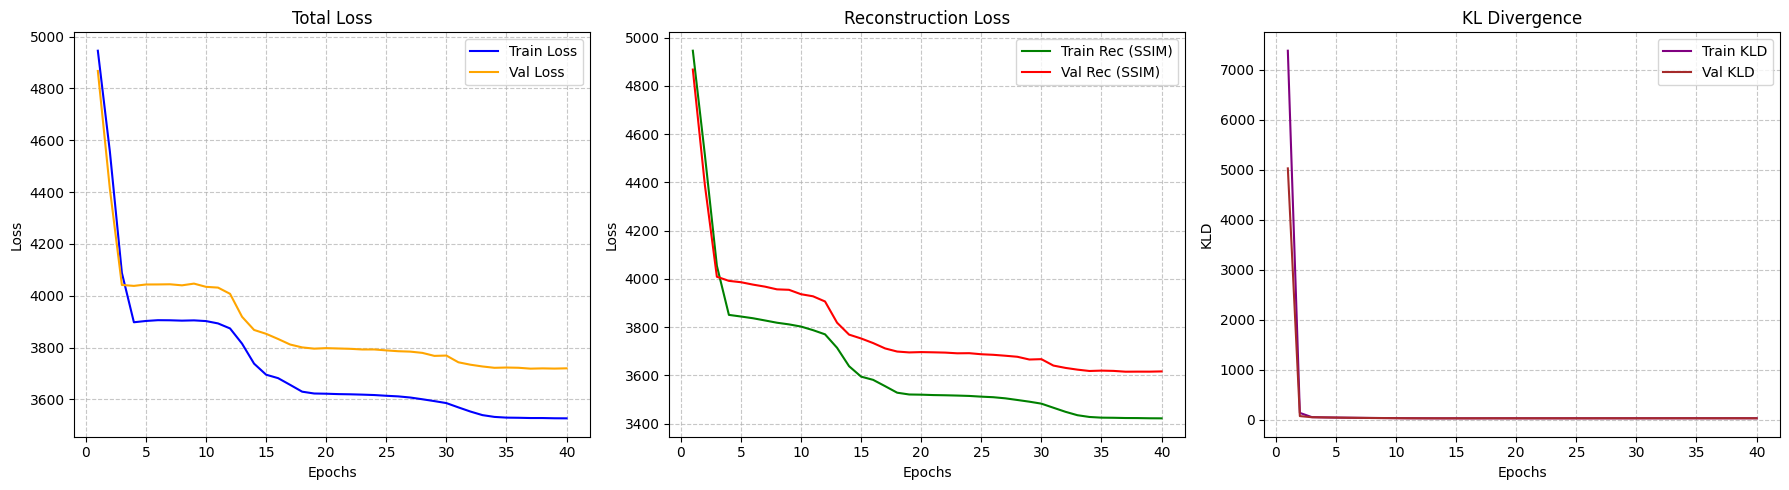

In [15]:
def plot_training_curves(history):
    # Determine the number of epochs trained so far
    epochs = range(1, len(history['train_loss']) + 1)

    # Create a 1x3 grid for our plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. Total Loss ---
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='orange')
    axes[0].set_title('Total Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- 2. Reconstruction Loss ---
    axes[1].plot(epochs, history['train_rec'], label='Train Rec (SSIM)', color='green')
    axes[1].plot(epochs, history['val_rec'], label='Val Rec (SSIM)', color='red')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- 3. KL Divergence ---
    axes[2].plot(epochs, history['train_kld'], label='Train KLD', color='purple')
    axes[2].plot(epochs, history['val_kld'], label='Val KLD', color='brown')
    axes[2].set_title('KL Divergence')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('KLD')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function to display the plots
plot_training_curves(history)